In [2]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
import os
from keras.models import Sequential
from keras.layers import Embedding, LSTM, Dense, Dropout
from keras.callbacks import ModelCheckpoint, CSVLogger

import os
from keras.models import Sequential
from keras.layers import Embedding, SimpleRNN, LSTM, Bidirectional, Dense, Dropout
from keras.callbacks import ModelCheckpoint, CSVLogger

[nltk_data] Downloading package stopwords to C:\Users\K BALA
[nltk_data]     GANESH\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
# Load dataset
path="D:/Project/FakeNewsDetection/dataset/"

# Load datasets
true_df = pd.read_csv(path+'True.csv')
fake_df = pd.read_csv(path+'Fake.csv')

# Add labels
true_df['label'] = 1  # Real news
fake_df['label'] = 0  # Fake news

# Combine datasets
df = pd.concat([true_df, fake_df], ignore_index=True)

# Shuffle
df = df.sample(frac=1).reset_index(drop=True)
df

,title,text,subject,date,label
0,Trump taps Retired General Kelly to lead Homel...,WASHINGTON (Reuters) - Republican U.S. Preside...,politicsNews,"December 12, 2016",1
1,Pennsylvania ex-attorney general gets jail tim...,"NORRISTOWN, Pa. (Reuters) - Former Pennsylvani...",politicsNews,"October 24, 2016",1
2,JUST IN: Mystery Surrounds Obama Appointee Jud...,"A federal judge in Washington, D.C. has recuse...",politics,"Dec 16, 2017",0
3,RNC Chief Strategist Has A FULL MELTDOWN On C...,The GOP has been impatiently waiting for the m...,News,"July 5, 2016",0
4,New fires ravage Rohingya villages in northwes...,YANGON (Reuters) - Up to eight villages were b...,worldnews,"September 9, 2017",1
...,...,...,...,...,...
44893,U.S. conservative group backs Republicans who ...,WASHINGTON (Reuters) - A conservative nonprofi...,politicsNews,"October 13, 2016",1
44894,Smog chokes Indian capital as emergency measur...,NEW DELHI (Reuters) - A thick cloud of toxic s...,worldnews,"November 13, 2017",1
44895,REPUBLICAN PROPOSES HOUSE BILL TO FORCE Suprem...,"Of course, we d be okay with excluding three o...",politics,"Jun 26, 2015",0
44896,UNHINGED: White Male GOP Rep. Makes COMPLETEL...,Rep. Jason Smith of Missouri spent Internation...,News,"March 11, 2017",0


In [4]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\W', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    words = text.split()
    filtered_words = [w for w in words if w not in stop_words]
    return ' '.join(filtered_words)

df['clean_text'] = df['text'].apply(clean_text)

In [14]:
df

,title,text,subject,date,label,clean_text
0,Trump taps Retired General Kelly to lead Homel...,WASHINGTON (Reuters) - Republican U.S. Preside...,politicsNews,"December 12, 2016",1,washington reuters republican u president elec...
1,Pennsylvania ex-attorney general gets jail tim...,"NORRISTOWN, Pa. (Reuters) - Former Pennsylvani...",politicsNews,"October 24, 2016",1,norristown pa reuters former pennsylvania atto...
2,JUST IN: Mystery Surrounds Obama Appointee Jud...,"A federal judge in Washington, D.C. has recuse...",politics,"Dec 16, 2017",0,federal judge washington c recused second case...
3,RNC Chief Strategist Has A FULL MELTDOWN On C...,The GOP has been impatiently waiting for the m...,News,"July 5, 2016",0,gop impatiently waiting moment presumptive dem...
4,New fires ravage Rohingya villages in northwes...,YANGON (Reuters) - Up to eight villages were b...,worldnews,"September 9, 2017",1,yangon reuters eight villages burned friday pa...
...,...,...,...,...,...,...
44893,U.S. conservative group backs Republicans who ...,WASHINGTON (Reuters) - A conservative nonprofi...,politicsNews,"October 13, 2016",1,washington reuters conservative nonprofit grou...
44894,Smog chokes Indian capital as emergency measur...,NEW DELHI (Reuters) - A thick cloud of toxic s...,worldnews,"November 13, 2017",1,new delhi reuters thick cloud toxic smog 10 ti...
44895,REPUBLICAN PROPOSES HOUSE BILL TO FORCE Suprem...,"Of course, we d be okay with excluding three o...",politics,"Jun 26, 2015",0,course okay excluding three justices go along ...
44896,UNHINGED: White Male GOP Rep. Makes COMPLETEL...,Rep. Jason Smith of Missouri spent Internation...,News,"March 11, 2017",0,rep jason smith missouri spent international w...


In [5]:
# Tokenizer
tokenizer = Tokenizer()
tokenizer.fit_on_texts(df['clean_text'])

X = tokenizer.texts_to_sequences(df['clean_text'])
maxlen = 300
X = pad_sequences(X, maxlen=maxlen)

y = df['label'].values

vocab_size = len(tokenizer.word_index) + 1

In [6]:
y

array([1, 1, 0, ..., 0, 0, 0], shape=(44898,))

In [7]:
from sklearn.model_selection import train_test_split

# Step 1: First split off the test set (10%)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# Step 2: Now split remaining data into train and validation (10% of total = 1/9 of remaining)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1111, random_state=42)

In [8]:
embedding_dim = 128

In [10]:
dir_path = "D:/Project/FakeNewsDetection/"
os.makedirs(dir_path+"Models", exist_ok=True)

# Define the models you want to train
model_types = ['rnn', 'lstm']
histories = {}
results = {}

# Build function
def build_model(model_type='rnn'):
    model = Sequential()
    model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=maxlen))
    
    if model_type == 'rnn':
        model.add(SimpleRNN(64, dropout=0.3, recurrent_dropout=0.3))
    elif model_type == 'lstm':
        model.add(LSTM(64, dropout=0.3, recurrent_dropout=0.3))
    
    model.add(Dropout(0.5))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model


In [11]:
import os
from keras.callbacks import ModelCheckpoint, CSVLogger

# Create directory for saving models
os.makedirs(dir_path+"Models", exist_ok=True)

In [12]:
for mtype in model_types:
    print(f"\n🔁 Training model: {mtype.upper()}")

    model = build_model(mtype)

    # Callbacks
    checkpoint = ModelCheckpoint(
        filepath=f'Models/{mtype.upper()}_epoch_{{epoch:02d}}_valacc_{{val_accuracy:.4f}}.keras',
        monitor='val_accuracy',
        save_best_only=False,
        verbose=1
    )
    csv_logger = CSVLogger(f'{mtype.upper()}_training_log.csv', append=True)

    # Train the model
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=5,
        batch_size=64,
        callbacks=[checkpoint, csv_logger],
        verbose=1
    )

    scores = model.evaluate(X_val, y_val, verbose=0)
    results[mtype] = scores
    histories[mtype] = history


🔁 Training model: RNN
Epoch 1/5


c:\Users\K BALA GANESH\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


562/562 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.5777 - loss: 0.6846
Epoch 1: saving model to Models/RNN_epoch_01_valacc_0.7857.keras

Epoch 1: finished saving model to Models/RNN_epoch_01_valacc_0.7857.keras
562/562 ━━━━━━━━━━━━━━━━━━━━ 97s 169ms/step - accuracy: 0.6091 - loss: 0.6474 - val_accuracy: 0.7857 - val_loss: 0.5562
Epoch 2/5
562/562 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.6674 - loss: 0.5866
Epoch 2: saving model to Models/RNN_epoch_02_valacc_0.7243.keras

Epoch 2: finished saving model to Models/RNN_epoch_02_valacc_0.7243.keras
562/562 ━━━━━━━━━━━━━━━━━━━━ 93s 165ms/step - accuracy: 0.6696 - loss: 0.5824 - val_accuracy: 0.7243 - val_loss: 0.5199
Epoch 3/5
562/562 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.6949 - loss: 0.5435
Epoch 3: saving model to Models/RNN_epoch_03_valacc_0.7898.keras

Epoch 3: finished saving model to Models/RNN_epoch_03_valacc_0.7898.keras
562/562 ━━━━━━━━━━━━━━━━━━━━ 101s 179ms/step - accuracy: 0.7036 - loss: 0.5368 - val_accu

In [15]:
from sklearn.metrics import classification_report, confusion_matrix, average_precision_score, jaccard_score

y_pred = model.predict(X_test)
y_pred_binary = (y_pred > 0.5).astype(int)

print(confusion_matrix(y_test, y_pred_binary))
print(classification_report(y_test, y_pred_binary))

mAP = average_precision_score(y_test, y_pred)
iou = jaccard_score(y_test, y_pred_binary)

print(f"mAP: {mAP:.4f}")
print(f"IoU: {iou:.4f}")

141/141 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step
[[2302   45]
 [  28 2115]]
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      2347
           1       0.98      0.99      0.98      2143

    accuracy                           0.98      4490
   macro avg       0.98      0.98      0.98      4490
weighted avg       0.98      0.98      0.98      4490

mAP: 0.9961
IoU: 0.9666


141/141 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step
Accuracy for RNN_epoch_05_valacc_0.8693: 0.9837416481069042
Precision for RNN_epoch_05_valacc_0.8693: 0.9791666666666666
Recall for RNN_epoch_05_valacc_0.8693: 0.9869342043863742
F1-score for RNN_epoch_05_valacc_0.8693: 0.9830350917964211


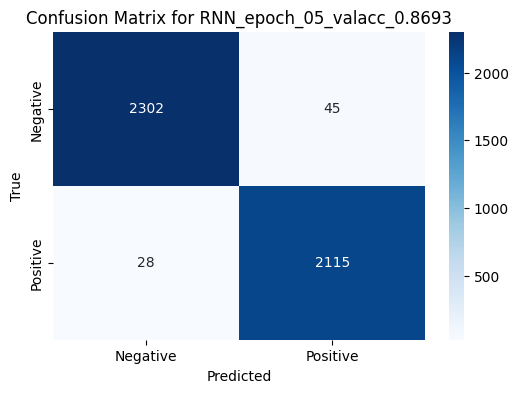

141/141 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step
Accuracy for LSTM_epoch_05_valacc_0.9857: 0.9837416481069042
Precision for LSTM_epoch_05_valacc_0.9857: 0.9791666666666666
Recall for LSTM_epoch_05_valacc_0.9857: 0.9869342043863742
F1-score for LSTM_epoch_05_valacc_0.9857: 0.9830350917964211


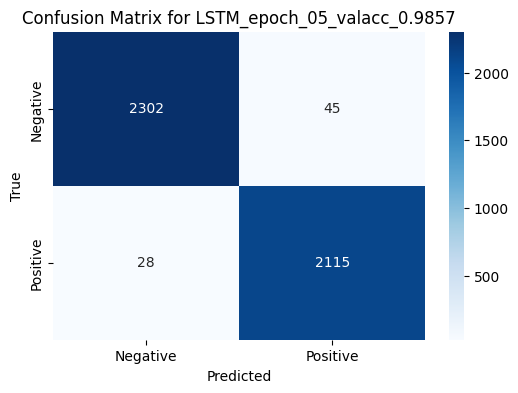

In [16]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import precision_recall_fscore_support
from keras.models import load_model
import matplotlib.pyplot as plt
import seaborn as sns

# List of model types to evaluate
model_types = ['RNN_epoch_05_valacc_0.8693',  'LSTM_epoch_05_valacc_0.9857']
histories = {}

# Load and evaluate each model
for model_type in model_types:
   
    
    # Predict using the model
    y_pred = model.predict(X_test)  # Assuming X_test is the test data
    y_pred_class = (y_pred > 0.5).astype(int)  # Convert probabilities to class labels (0 or 1)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred_class)
    precision = precision_score(y_test, y_pred_class)
    recall = recall_score(y_test, y_pred_class)
    f1 = f1_score(y_test, y_pred_class)
    conf_matrix = confusion_matrix(y_test, y_pred_class)
    
    # Print out the results
    print(f'Accuracy for {model_type}: {accuracy}')
    print(f'Precision for {model_type}: {precision}')
    print(f'Recall for {model_type}: {recall}')
    print(f'F1-score for {model_type}: {f1}')
    
    # Plot confusion matrix
    plt.figure(figsize=(6, 4))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Confusion Matrix for {model_type}')
    plt.show()
    
    # Store the model's history (if needed for further analysis)
    histories[model_type] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'conf_matrix': conf_matrix
    }

In [17]:
dir_path_model = "D:/Project/FakeNewsDetection/Models/"
model_path = dir_path_model+"final_model.keras"
model.save(model_path)
model_path_h5 = dir_path_model+"final_model.h5"
model.save(model_path_h5)


In [20]:
!python -m pip install textstat

   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ----------------------------------- ---- 1.8/2.1 MB 12.6 MB/s eta 0:00:01
   ---------------------------------------- 2.1/2.1 MB 10.6 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [30]:
import textstat
from textblob import TextBlob

def extract_text_features(text):
    blob = TextBlob(text)
    word_count = len(blob.words)
    sentence_count = len(blob.sentences)
    avg_word_length = sum(len(word) for word in blob.words) / word_count if word_count else 0
    avg_sentence_length = word_count / sentence_count if sentence_count else 0
    polarity = blob.sentiment.polarity
    subjectivity = blob.sentiment.subjectivity
    readability = textstat.flesch_reading_ease(text)
    
    return pd.Series([
        word_count,
        avg_word_length,
        avg_sentence_length,
        polarity,
        subjectivity,
        readability
    ])

df_features = df['clean_text'].apply(extract_text_features)
df_features.columns = [
    'word_count', 'avg_word_len', 'avg_sent_len',
    'polarity', 'subjectivity', 'readability'
]

# Add label
df_features['label'] = df['label']
df_features

,word_count,avg_word_len,avg_sent_len,polarity,subjectivity,readability,label
0,51.0,7.000000,51.0,0.050000,0.400000,-35.694706,1
1,266.0,6.627820,266.0,0.005729,0.452083,-241.896353,1
2,240.0,6.266667,240.0,0.007895,0.235088,-202.440000,0
3,296.0,6.459459,296.0,-0.045694,0.621019,-263.090811,0
4,267.0,6.179775,267.0,0.113067,0.373622,-224.181236,1
...,...,...,...,...,...,...,...
44893,284.0,6.246479,284.0,0.090758,0.454192,-255.093310,1
44894,376.0,6.053191,376.0,0.010540,0.358926,-336.222000,1
44895,230.0,6.565217,230.0,0.115963,0.448065,-198.021957,0
44896,294.0,5.789116,294.0,0.004536,0.511289,-246.675000,0



🧠 Training Logistic Regression...
Accuracy: 0.7006681514476615
[[3445 1304]
 [1384 2847]]
              precision    recall  f1-score   support

           0       0.71      0.73      0.72      4749
           1       0.69      0.67      0.68      4231

    accuracy                           0.70      8980
   macro avg       0.70      0.70      0.70      8980
weighted avg       0.70      0.70      0.70      8980


🧠 Training Random Forest...
Accuracy: 0.8130289532293986
[[3982  767]
 [ 912 3319]]
              precision    recall  f1-score   support

           0       0.81      0.84      0.83      4749
           1       0.81      0.78      0.80      4231

    accuracy                           0.81      8980
   macro avg       0.81      0.81      0.81      8980
weighted avg       0.81      0.81      0.81      8980


🧠 Training KNN...
Accuracy: 0.7256124721603563
[[3469 1280]
 [1184 3047]]
              precision    recall  f1-score   support

           0       0.75      0.73      0

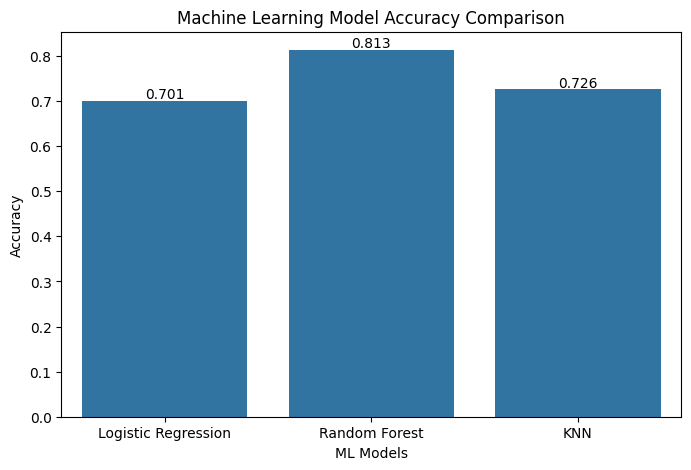

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Prepare data
X_feat = df_features.drop('label', axis=1)
y_feat = df_features['label']

X_train_feat, X_test_feat, y_train_feat, y_test_feat = train_test_split(
    X_feat, y_feat, test_size=0.2, random_state=42
)

# Normalize features
scaler = StandardScaler()
X_train_feat = scaler.fit_transform(X_train_feat)
X_test_feat = scaler.transform(X_test_feat)

# Models
models = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(),
    'KNN': KNeighborsClassifier()
}

ml_results = {}

# Train models
for name, model in models.items():
    
    print(f"\n🧠 Training {name}...")
    
    model.fit(X_train_feat, y_train_feat)
    
    preds = model.predict(X_test_feat)

    # Accuracy
    acc = accuracy_score(y_test_feat, preds)
    ml_results[name] = acc

    print("Accuracy:", acc)
    print(confusion_matrix(y_test_feat, preds))
    print(classification_report(y_test_feat, preds))


# ---------------------------
# 📊 ML Model Comparison Chart
# ---------------------------

results_df = pd.DataFrame({
    "Model": list(ml_results.keys()),
    "Accuracy": list(ml_results.values())
})

plt.figure(figsize=(8,5))

sns.barplot(data=results_df, x="Model", y="Accuracy")

plt.title("Machine Learning Model Accuracy Comparison")
plt.xlabel("ML Models")
plt.ylabel("Accuracy")

# Show accuracy values on bars
for index, row in results_df.iterrows():
    plt.text(index, row.Accuracy + 0.005, round(row.Accuracy,3), ha='center')

plt.show()

In [32]:
import joblib
from sklearn.metrics import accuracy_score

best_model = None
best_accuracy = 0
best_model_name = ""

for name, model in models.items():



    model.fit(X_train_feat, y_train_feat)

    preds = model.predict(X_test_feat)

    acc = accuracy_score(y_test_feat, preds)

    

    # Check if best model
    if acc > best_accuracy:
        best_accuracy = acc
        best_model = model
        best_model_name = name


# Save best model
joblib.dump(best_model, dir_path_model+"best_ml_model.pkl")

print(f"\n✅ Best Model: {best_model_name}")
print(f"✅ Accuracy: {best_accuracy}")
print("✅ Model saved as best_ml_model.pkl")


✅ Best Model: Random Forest
✅ Accuracy: 0.8110244988864143
✅ Model saved as best_ml_model.pkl
